In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
f1_score,matthews_corrcoef,classification_report,
confusion_matrix,ConfusionMatrixDisplay)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau


Original Shape: (128799, 67)
After Cleaning: (92035, 67)


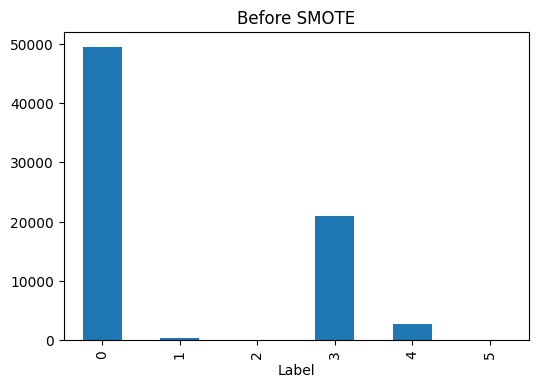

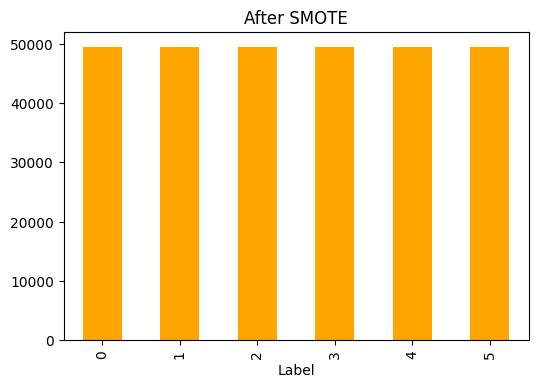

{np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0), np.int64(3): np.float64(1.0), np.int64(4): np.float64(1.0), np.int64(5): np.float64(1.0)}


In [ ]:
# Load Dataset
df = pd.read_csv("MSCAD.csv")

print("Original Shape:", df.shape)

df = df.drop_duplicates().dropna()

print("After Cleaning:", df.shape)

le = LabelEncoder()
df["Label"] = le.fit_transform(df["Label"])

X = df.drop("Label", axis=1)
y = df["Label"]

# Remove constant features
vt = VarianceThreshold(0)
X = vt.fit_transform(X)

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42)

# Visualize class distribution
plt.figure(figsize=(6,4))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar')
plt.title("Before SMOTE")
plt.show()

# SMOTE
sm = SMOTE(random_state=42,k_neighbors=1)
X_train,y_train = sm.fit_resample(X_train,y_train)

plt.figure(figsize=(6,4))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar',color='orange')
plt.title("After SMOTE")
plt.show()

classes=np.unique(y_train)
weights=compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights=dict(zip(classes,weights))
print(class_weights)


In [ ]:
model=Sequential([
Dense(256,activation='relu',input_shape=(X_train.shape[1],)),
BatchNormalization(),
Dropout(0.3),

Dense(128,activation='relu'),
BatchNormalization(),
Dropout(0.3),

Dense(64,activation='relu'),
BatchNormalization(),
Dropout(0.2),

Dense(32,activation='relu'),
BatchNormalization(),
Dropout(0.2),

Dense(len(np.unique(y_train)),activation='softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,502 (244.15 KB)

 Trainable params: 61,542 (240.40 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
early=EarlyStopping(
monitor='val_loss',
patience=5,
restore_best_weights=True)

lr=ReduceLROnPlateau(
monitor='val_loss',
factor=0.5,
patience=3,
min_lr=1e-6)

history=model.fit(
X_train,
y_train,
epochs=50,
batch_size=64,
validation_split=0.2,
callbacks=[early,lr],
class_weight=class_weights,
verbose=1)


Epoch 1/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.9337 - loss: 0.1989 - val_accuracy: 0.1569 - val_loss: 5.9306 - learning_rate: 0.0010
Epoch 2/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.9548 - loss: 0.1370 - val_accuracy: 0.1567 - val_loss: 6.5465 - learning_rate: 0.0010
Epoch 3/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.9616 - loss: 0.1186 - val_accuracy: 0.1577 - val_loss: 6.3805 - learning_rate: 0.0010
Epoch 4/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.9645 - loss: 0.1098 - val_accuracy: 0.1591 - val_loss: 5.9259 - learning_rate: 0.0010
Epoch 5/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.9662 - loss: 0.1061 - val_accuracy: 0.1576 - val_loss: 5.9894 - learning_rate: 0.0010
Epoch 6/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.9688 - loss: 0.0998 - val_accuracy: 0.1584 - val_loss: 5.8449 - learning_rate: 0.0010
Epoch 7/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.

In [ ]:
loss,acc=model.evaluate(X_test,y_test,verbose=0)
print("Test Accuracy:",acc)

y_prob=model.predict(X_test)
y_pred=np.argmax(y_prob,axis=1)

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision :",precision_score(y_test,y_pred,average='weighted'))
print("Recall :",recall_score(y_test,y_pred,average='weighted'))
print("F1 :",f1_score(y_test,y_pred,average='weighted'))
print("MCC :",matthews_corrcoef(y_test,y_pred))

print(classification_report(y_test,y_pred))


Test Accuracy: 0.9896778464317322
576/576 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.989677839952192
Precision : 0.9927566693974053
Recall : 0.989677839952192
F1 : 0.9910838308107883
MCC : 0.9778934853372308
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     12404
           1       0.85      0.90      0.87        88
           2       0.07      0.56      0.12         9
           3       0.99      0.98      0.99      5242
           4       0.91      0.96      0.93       658
           5       0.00      0.00      0.00         6

    accuracy                           0.99     18407
   macro avg       0.64      0.73      0.65     18407
weighted avg       0.99      0.99      0.99     18407



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

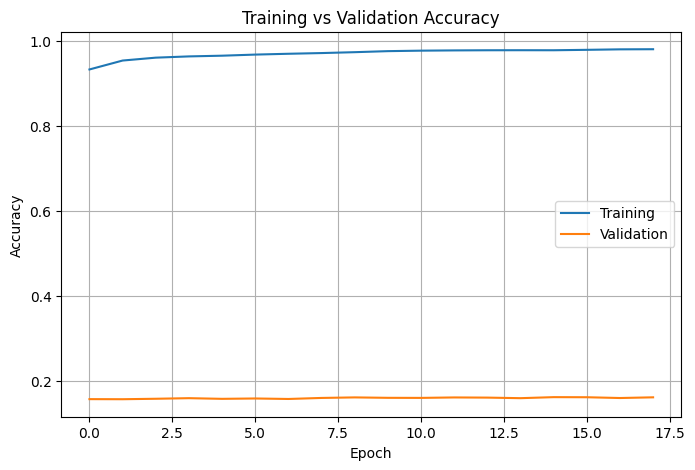

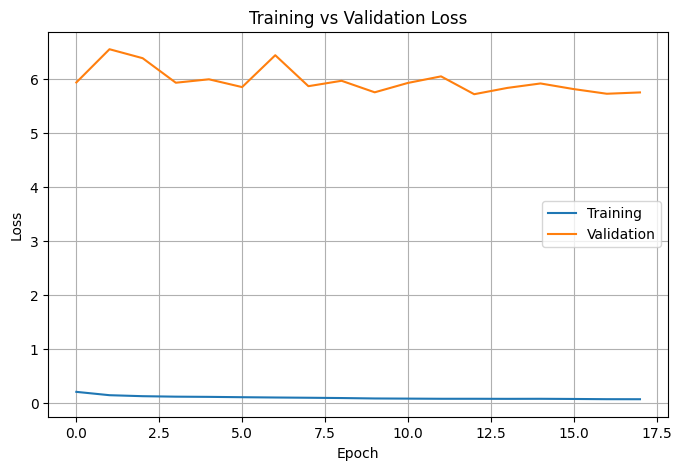

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()